# Preface

In this notebook, we apply model-based algorithms to solve a simple RL problem: FrozenLake.

The main purpose is to introduce the algorithm and also the `OpenAI Gym` environment that allows easy testing of RL algorithms.

In [ ]:
!pip install gym
!pip install gymnasium==0.28.1
!pip install numpy
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.5/925.5 kB 1.9 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.1.1
    Uninstalling gymnasium-1.1.1:
      Successfully uninstalled gymnasium-1.1.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.28.1 which is incompatible.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('notebook', font_scale=1.25, rc={"lines.linewidth": 2.5})
sns.set_style("darkgrid")
np.random.seed(123)  # For reproducibility

import warnings
warnings.filterwarnings("ignore")

# FrozenLake and the OpenAI Gym Environment

`OpenAI Gym` is a benchmarking platform for reinforcement learning algorithms. It provides a unified API to specify environments.

   
You can read more about it [here](https://www.gymlibrary.dev/index.html).

In [ ]:
import gym

We are going to use a specific environment The **FrozenLake**:

The environment consists of 4x4=16 tiles of 4 types:
   * S = starting point, safe
   * F = frozen surface, safe
   * H = hole, unsafe
   * G = goal
   
The agent navigates the environment by choosing an action: left, right, up or down.

However, the world is *slippery*, so that even if you choose an action, you might not always end up where you are! We will see this later.

The goal of the agent is to get to the G (goal) tile, without dropping into the H (hole) tile. When either G or H are reached, the game terminates. The agent receives reward of +1 only when it ends up on a G tile.

![Image](https://miro.medium.com/max/842/1*Qp14HWQfOeE2UoSxrxCxAg.png)

We can create this environment directly using `make`.

In [ ]:
# Create the FrozenLake environment (version v1)
env = gym.make('FrozenLake-v1')
# Reset the environment to its initial state
env.reset()

/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


0

# Transition Probability

Let us look at the *transition probability*
$$
    p(s', r| s, a)
$$

This is stored in `env.P`. Each `env.P[s][a]` is a list, with each element `env.P[s][a][j]` a tuple
$$
    \left(
        p(s_j,r_j|s,a),
        s_j,
        r_j,
        \text{Status}
    \right)
$$
`Status` equals `True` if the episode ends. Otherwise it is `False`.

Note that in this game, the actions are organized as
```
    0: left
    1: down
    2: right
    3: up
```

For example, we can look at the transition probability at the first state, if we were to go downwards ($a=1$)

In [ ]:
env.P[0][1]

[(0.3333333333333333, 0, 0.0, False),
 (0.3333333333333333, 4, 0.0, False),
 (0.3333333333333333, 1, 0.0, False)]

We make a step, calling the `step` method, which applies the action to the system.

The method returns a tuple (next_state, reward, terminated, truncated, info)
- **`state`**: The observation after taking the action.
- **`reward`**: The immediate reward from the action.
- **`terminated`**: `True` if the episode ended naturally.
- **`truncated`**: `True` if the episode ended due to a time or step limit.
- **`info`**: A dictionary with additional environment-specific information.

In [ ]:
# Update the code to unpack the expected number of values.
# Gym v0.26.0 and above returns 5 values:
# (observation, reward, terminated, truncated, info)
# For older versions, 'done' is used instead of 'terminated' and 'truncated'

try:
    observation, reward, terminated, truncated, info = env.step(action=1)
except ValueError:
    observation, reward, done, info = env.step(action=1)
    terminated = done
    truncated = False  # Assume not truncated in older versions if not provided

# If you need the 'state', it is now typically referred to as 'observation'
state = observation

# Print the results
print(f"State: {state}\nReward: {reward}\nTerminated: {terminated}\nTruncated: {truncated}\nInfo: {info}")

State: 5
Reward: 0
Terminated: True
Truncated: False
Info: {'prob': 1.0, 'TimeLimit.truncated': False}


Let's now go right...

In [ ]:
env.P[state][2]

[(1.0, 5, 0, True)]

In [ ]:
# Update the code to unpack the expected number of values.
# Gym v0.26.0 and above returns 5 values:
# (observation, reward, terminated, truncated, info)
# For older versions, 'done' is used instead of 'terminated' and 'truncated'

try:
    observation, reward, terminated, truncated, info = env.step(action=1)
except ValueError:
    observation, reward, done, info = env.step(action=1)
    terminated = done
    truncated = False  # Assume not truncated in older versions if not provided

# If you need the 'state', it is now typically referred to as 'observation'
state = observation

# Print the results
print(f"State: {state}\nReward: {reward}\nTerminated: {terminated}\nTruncated: {truncated}\nInfo: {info}")

State: 5
Reward: 0
Terminated: True
Truncated: False
Info: {'prob': 1.0, 'TimeLimit.truncated': False}


# Model Based Policy Iteration

## Policy Evaluation

Given policy $\pi$, we evaluate $v_\pi(s)$ for all $s\in\mathcal{S}$.

This is done by an iterative solution of the Bellman's equation.

In [ ]:
def policy_evaluation(env, policy, gamma, max_iter):
    """
    Evaluate a (deterministic) policy
        Here, a policy is an iterable of size nS (number of states)
        giving an action to take for each state

        Other stopping criteria are also possible
    """
    value_function = np.zeros(env.observation_space.n)

    for _ in range(max_iter):
        tmp = np.zeros_like(value_function)

        # Compute right hand side of Bellman Equation
        for state, action in enumerate(policy):
            for probablity, next_state, reward, _ in env.P[state][action]:
                # Bellman equation update: V(s) = Σ P(s',r|s,a) * (r + γ * V(s'))
                tmp[state] += probablity * (reward + gamma * value_function[next_state])
        value_function = tmp

    return value_function

Let us evaluate the value function of a randomly generated policy

In [ ]:
# Randomly initialize a policy by selecting an action for each state
# np.random.choice selects a random action from the action space for each state
policy = np.random.choice(range(env.action_space.n), size=(env.observation_space.n))

value_function = policy_evaluation(env=env, policy=policy, gamma=1.0, max_iter=1000)

print(value_function)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


<Axes: >

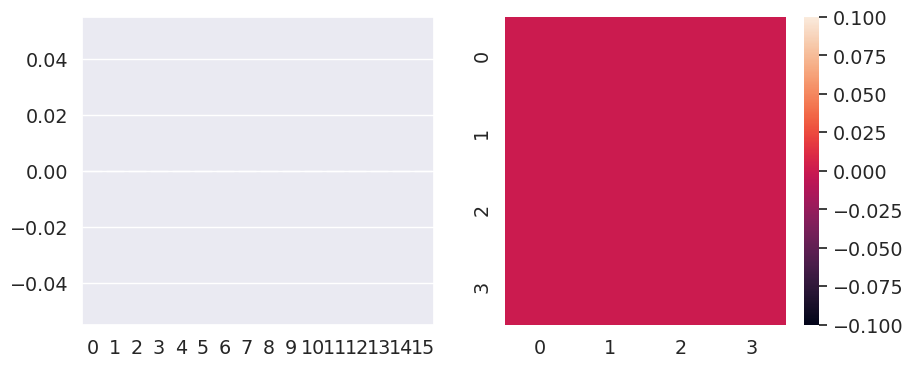

In [ ]:
env.reset()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(x = np.arange(env.observation_space.n), y = value_function, ax=ax[0])
sns.heatmap(value_function.reshape(4, 4), ax=ax[1])

## Policy Improvement

Given a policy $\pi$, we can improve it by computing the *action value function*
$$
    q_\pi(s, a) = \sum_{s',r} p(s',r|s,a)(r + \gamma v_\pi(s'))
$$

Given an action value function, we improve policy by
$$
    \pi'(s) = \mathrm{arg\,max}_{a} q_\pi(s, a)
$$

In [ ]:
def compute_action_value(env, state, value_function, gamma):
    """
    Computes q(state, \cdot)
    """
    action_values = np.zeros(env.action_space.n)
    for action in range(env.action_space.n):
        for probablity, next_state, reward, info in env.P[state][action]:
            action_values[action] += probablity * (reward + (gamma * value_function[next_state]))
    return action_values

<>:2: DeprecationWarning: invalid escape sequence '\c'


In [ ]:
def policy_improvement(env, value_function, gamma):
    """
    Improve a current policy by acting greedily with respect
    to the action value function
    """
    policy = np.zeros(env.observation_space.n)
    for state in range(env.observation_space.n):
        action_values = compute_action_value(env, state, value_function, gamma)
        policy[state] = np.argmax(action_values)  # pick action to maximize action-value
    return policy

We take the randomized policy as before. To visualize it we define an action map

In [ ]:
action_map = {
    0: '\u2190',
    1: '\u2193',
    2: '\u2192',
    3: '\u2191',
}
print(action_map)

{0: '←', 1: '↓', 2: '→', 3: '↑'}


In [ ]:
def visualize_policy(policy):
    grid = np.array(
        [
            ['S', 'F', 'F', 'F'],
            ['F', 'H', 'F', 'H'],
            ['F', 'F', 'F', 'H'],
            ['H', 'F', 'F', 'G'],
        ]
    )
    directions = np.array([action_map[p] for p in policy]).reshape(4, 4)
    print(grid)
    print(directions)

In [ ]:
visualize_policy(policy)

[['S' 'F' 'F' 'F']
 ['F' 'H' 'F' 'H']
 ['F' 'F' 'F' 'H']
 ['H' 'F' 'F' 'G']]
[['→' '↓' '→' '→']
 ['←' '→' '→' '↓']
 ['↑' '→' '↑' '↓']
 ['→' '↓' '←' '↓']]


In [ ]:
updated_policy = policy_improvement(env=env, value_function=value_function, gamma=1.0)

In [ ]:
visualize_policy(updated_policy)

[['S' 'F' 'F' 'F']
 ['F' 'H' 'F' 'H']
 ['F' 'F' 'F' 'H']
 ['H' 'F' 'F' 'G']]
[['←' '←' '←' '←']
 ['←' '←' '←' '←']
 ['←' '←' '←' '←']
 ['←' '←' '↓' '←']]


## Policy Iteration

Putting things together, we can iterate the steps of policy evaluation and improvement.

In [ ]:
def policy_iteration(env, max_iter=100):
    """
    Model-Based Policy Iteration Algorithm
    """

    # intialize a random policy
    policy = np.random.choice(range(env.action_space.n), size=(env.observation_space.n))
    # maintain a copy to check for convergence
    policy_prev = np.copy(policy)

    for i in range(max_iter):

        # evaluate policy
        value_function = policy_evaluation(env, policy, 1.0, 100)

        # improve policy
        policy = policy_improvement(env, value_function, 1.0)

    return value_function, policy

In [ ]:
value_function, policy = policy_iteration(env, max_iter=100)

<Axes: >

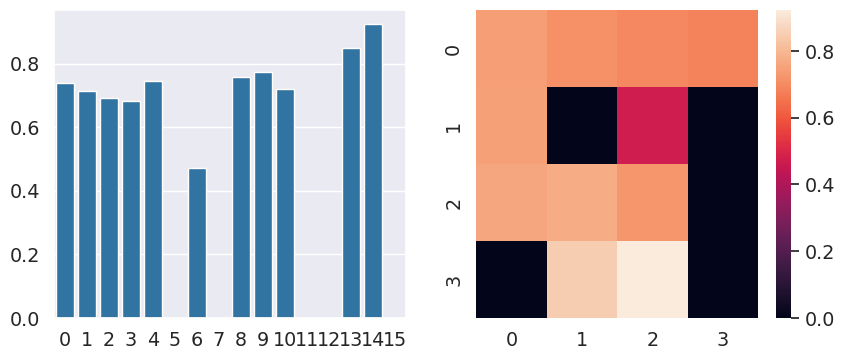

In [ ]:
env.reset()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(x = np.arange(env.observation_space.n), y = value_function, ax=ax[0])
sns.heatmap(value_function.reshape(4, 4), ax=ax[1])

In [ ]:
visualize_policy(policy)

[['S' 'F' 'F' 'F']
 ['F' 'H' 'F' 'H']
 ['F' 'F' 'F' 'H']
 ['H' 'F' 'F' 'G']]
[['←' '↑' '↑' '↑']
 ['←' '←' '←' '←']
 ['↑' '↓' '←' '←']
 ['←' '→' '↓' '←']]
